<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/DL/regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sb
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [5]:
X, y = make_moons(100, noise = 0.25, random_state = 2)

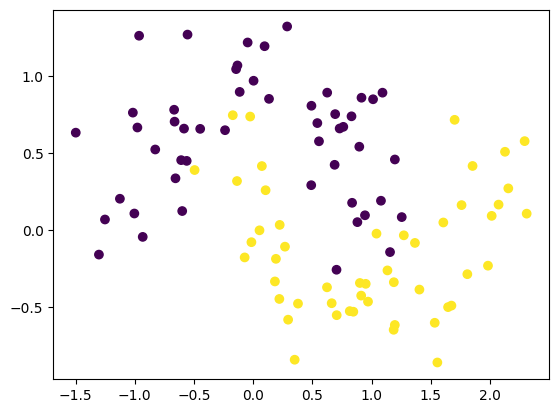

In [7]:
plt.scatter(X[:,0], X[:,1], c=y)

In [9]:
model1 = Sequential()
model1.add(Dense(128, input_dim=2, activation ='relu'))
model1.add(Dense(128, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
adam = Adam(learning_rate=0.01)
model1.compile(loss = 'binary_crossentropy', optimizer=adam, metrics=['accuracy'])

In [12]:
history1 = model1.fit(X, y, epochs=2000, validation_split=0.2, verbose=1)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.6375 - loss: 0.6327 - val_accuracy: 0.9000 - val_loss: 0.3283
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8102 - loss: 0.4375 - val_accuracy: 0.9000 - val_loss: 0.2052
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8305 - loss: 0.4003 - val_accuracy: 0.9000 - val_loss: 0.1681
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8391 - loss: 0.4228 - val_accuracy: 0.9000 - val_loss: 0.2524
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8562 - loss: 0.3216 - val_accuracy: 0.9000 - val_loss: 0.2683
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8391 - loss: 0.3354 - val_accuracy: 0.9000 - val_loss: 0.2383
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8570 - loss: 0.3462 - val_accuracy: 0.9000 - val_loss: 0.2185
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8820 - loss: 0.2883 - val_accuracy: 0.9000 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

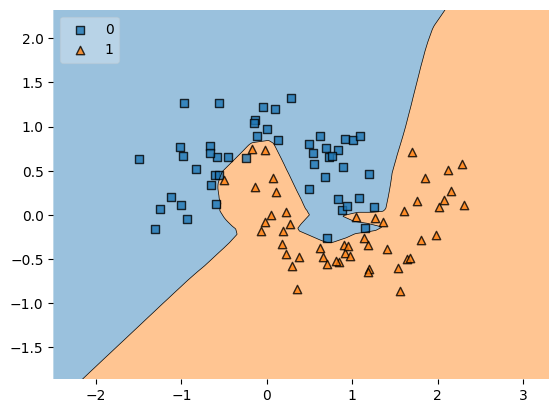

In [13]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend = 2)
plt.show()

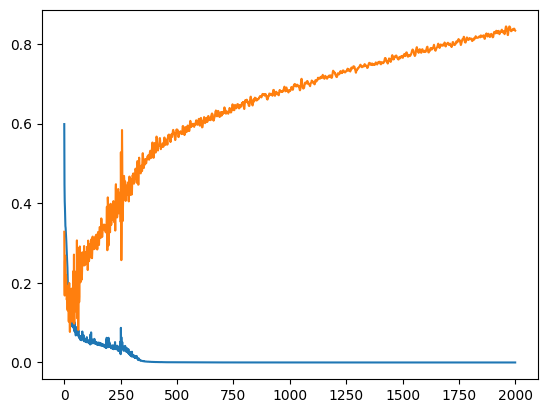

In [14]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.show()

In [18]:
model2 = Sequential()
model2.add(Dense(128, input_dim=2, activation='relu', kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation='relu', kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split=0.2, verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


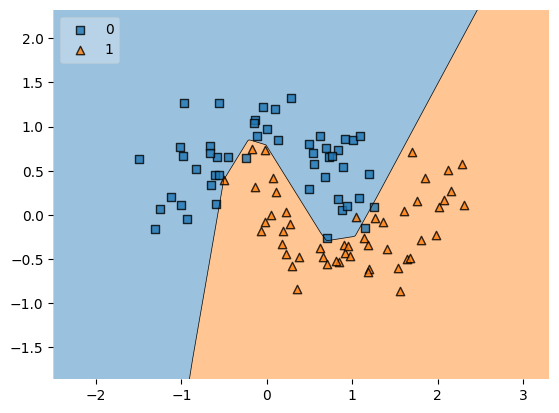

In [21]:
plot_decision_regions(X, y.astype('int'), clf = model2, legend=2)
plt.show()

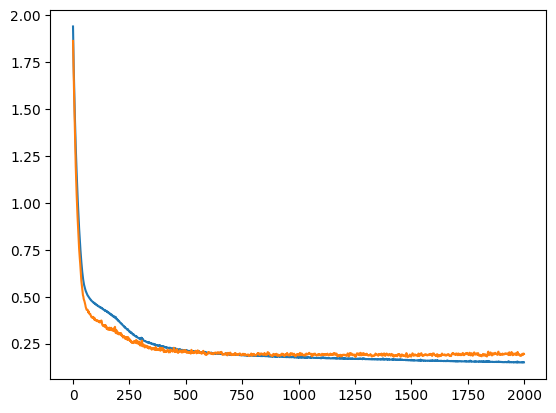

In [22]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [24]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

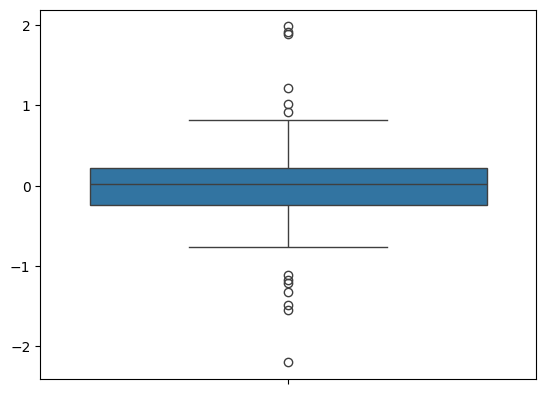

In [31]:
sb.boxplot(model1_weight_layer1, vert=True)

<Axes: >

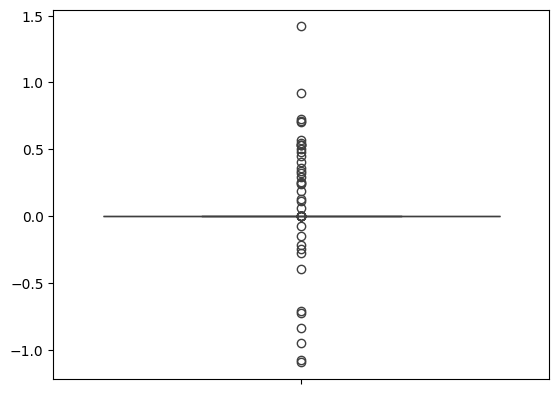

In [33]:
sb.boxplot(model2_weight_layer1)

In [34]:
model1_weight_layer1.min()

np.float32(-2.1975503)

In [36]:
model2_weight_layer1.max()

np.float32(1.4193822)

/tmp/ipython-input-1027127012.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(model1_weight_layer1)
/tmp/ipython-input-1027127012.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

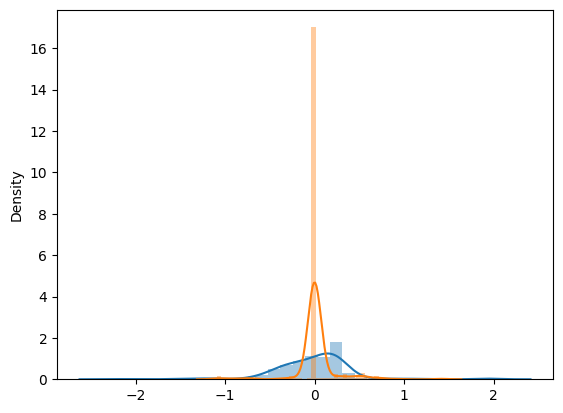

In [37]:
sb.distplot(model1_weight_layer1)
sb.distplot(model2_weight_layer1)

In [38]:
model1.get_weights()[0].reshape(256)

array([-1.39665976e-01,  4.34439093e-01,  2.63018101e-01, -3.77692997e-01,
       -2.84955680e-01, -6.55895919e-02, -5.97450696e-02, -2.35091880e-01,
       -2.35935319e-02,  7.98444897e-02, -5.50799131e-01, -8.64506736e-02,
        8.00182926e-04, -1.80804759e-01, -2.41687134e-01, -3.49180028e-02,
        2.51095206e-01,  3.03254366e-01,  2.78081238e-01, -4.31742847e-01,
       -4.24565285e-01, -4.07318771e-01,  1.73858721e-02, -1.51958480e-01,
        9.43678096e-02,  8.31836015e-02, -2.72196263e-01, -4.63296473e-01,
        9.48224366e-02, -3.50958645e-01, -1.68625355e-01,  5.34565048e-03,
       -4.29193377e-01,  2.97254831e-01,  7.82587975e-02,  2.50920027e-01,
        3.14778328e-01, -4.82376665e-01,  1.77997455e-01,  2.80634731e-01,
       -3.46869022e-01,  3.31766754e-01,  2.05711991e-01,  5.08325025e-02,
        1.57739431e-01, -5.31064749e-01, -4.39741462e-02,  1.87581331e-01,
       -5.28483808e-01, -5.14224946e-01, -9.12563205e-02, -4.82934229e-02,
        2.17858449e-01, -